# Piece Value Estimation Using LRP

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Xmaster6y/lczerolens/blob/main/docs/source/notebooks/tutorials/piece-value-estimation-using-lrp.ipynb)

## Setup

In [6]:
import importlib.util

DEV = True

if importlib.util.find_spec("google.colab") is not None:
    MODE = "colab-dev" if DEV else "colab"
else:
    MODE = "local"

In [7]:
if MODE == "colab":
    %pip install -q lczerolens
elif MODE == "colab-dev":
    !rm -r lczerolens
    !git clone https://github.com/Xmaster6y/lczerolens -b main
    %pip install -q ./lczerolens

## Load a Model

Load a leela networks from hf:

In [8]:
from lczerolens import LczeroModel

strong_model = LczeroModel.from_hf("lczerolens/256x19-4508")
weak_model = LczeroModel.from_hf("lczerolens/256x19-1876")

In [9]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensordict import TensorDict
from tdhook.attribution import Saliency
from lczerolens import LczeroBoard

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
N_SAMPLES = 512
BATCH_SIZE = 32
PIECE_ORDER = ["pawn", "knight", "bishop", "rook", "queen", "king"]
PIECE_NAMES = [
    "my_pawn",
    "my_knight",
    "my_bishop",
    "my_rook",
    "my_queen",
    "my_king",
    "opp_pawn",
    "opp_knight",
    "opp_bishop",
    "opp_rook",
    "opp_queen",
    "opp_king",
]

strong_model = strong_model.to(DEVICE)
weak_model = weak_model.to(DEVICE)
print(f"Using device: {DEVICE}")


def init_wdl_targets(td: TensorDict, _):
    value = td["wdl"][:, 0] - td["wdl"][:, 2]
    return TensorDict({"value": value}, batch_size=td.batch_size)


def _iter_moves(moves):
    if isinstance(moves, str):
        return moves.split()
    return moves


def rows_to_boards(rows):
    boards = []
    for row in rows:
        fen = row.get("fen")
        if not fen:
            continue
        try:
            board = LczeroBoard(fen)
            for move in _iter_moves(row.get("moves", [])):
                board.push_uci(move)
            boards.append(board)
        except Exception:
            continue
    return boards


def estimate_piece_values(model, boards, batch_size=BATCH_SIZE):
    saliency = Saliency(init_attr_targets=init_wdl_targets)

    avg_relevance_sum = torch.zeros(12)
    avg_relevance_count = torch.zeros(12)

    with saliency.prepare(model) as hooked_model:
        for i in range(0, len(boards), batch_size):
            batch_boards = boards[i : i + batch_size]
            if not batch_boards:
                continue

            batch_tensor = model.prepare_boards(*batch_boards).to(DEVICE)
            td = TensorDict({"board": batch_tensor}, batch_size=[len(batch_boards)], device=batch_tensor.device)
            out = hooked_model(td)

            attr = out.get(("attr", "board"), None)
            if attr is None:
                attr = out.get(("attr", "input"), None)
            if attr is None:
                raise KeyError(f"Attribution tensor not found in output keys: {out.keys(True, True)}")

            attr = attr.detach().cpu()[:, :12]
            planes = td["board"].detach().cpu()[:, :12]

            piece_relevance = attr
            piece_occupancy = planes.abs() > 0

            rel_per_piece = (piece_relevance * piece_occupancy).sum(dim=(2, 3))
            count_per_piece = piece_occupancy.sum(dim=(2, 3))

            valid = count_per_piece > 0
            mean_rel = rel_per_piece / count_per_piece.clamp(min=1)

            avg_relevance_sum += torch.where(valid, mean_rel, torch.zeros_like(mean_rel)).sum(dim=0)
            avg_relevance_count += valid.sum(dim=0)

    avg_relevance = avg_relevance_sum / avg_relevance_count.clamp(min=1)
    avg_relevance = {name: avg_relevance[i].item() for i, name in enumerate(PIECE_NAMES)}

    own_equivalent = {piece: avg_relevance[f"my_{piece}"] - avg_relevance[f"opp_{piece}"] for piece in PIECE_ORDER}

    pawn_scale = own_equivalent["pawn"]
    if pawn_scale == 0:
        raise RuntimeError("Estimated pawn relevance is zero; cannot normalise piece values.")

    if pawn_scale < 0:
        own_equivalent = {k: -v for k, v in own_equivalent.items()}
        pawn_scale = -pawn_scale

    normalised = {k: v / pawn_scale for k, v in own_equivalent.items()}
    return normalised, avg_relevance


raw_stream = load_dataset("lczero-planning/boards", split="train", streaming=True)
rows = list(raw_stream.shuffle(seed=SEED, buffer_size=10_000).take(N_SAMPLES))
boards = rows_to_boards(rows)
if not boards:
    raise RuntimeError("No valid boards were parsed from the dataset sample.")
print(f"Using {len(boards)} boards.")

strong_values, strong_all_planes = estimate_piece_values(strong_model, boards)
weak_values, weak_all_planes = estimate_piece_values(weak_model, boards)

results = pd.DataFrame(
    {
        "strong_model": [strong_values[p] for p in PIECE_ORDER],
        "weak_model": [weak_values[p] for p in PIECE_ORDER],
    },
    index=PIECE_ORDER,
)
results

Using device: cpu
Using 512 boards.


,strong_model,weak_model
pawn,1.000000,1.000000
knight,1.202841,2.873729
bishop,1.021254,3.060443
rook,1.772798,4.453226
queen,1.653499,6.682118
king,-0.040027,0.122120


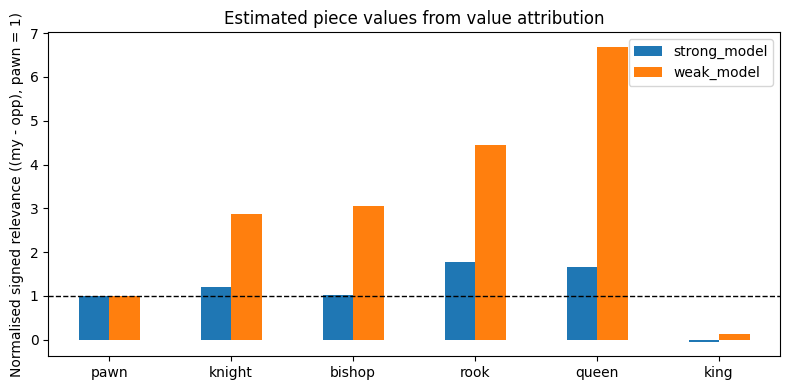

pawn      0.000000
knight   -1.670888
bishop   -2.039189
rook     -2.680428
queen    -5.028619
king     -0.162147
Name: strong_minus_weak, dtype: float64

In [10]:
ax = results.plot(kind="bar", figsize=(8, 4), rot=0)
ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
ax.set_ylabel("Normalised signed relevance ((my - opp), pawn = 1)")
ax.set_title("Estimated piece values from value attribution")
plt.tight_layout()
plt.show()

(results["strong_model"] - results["weak_model"]).rename("strong_minus_weak")